# Problem 1
### LSTM for Multivariate Forecasting

Build an LSTM model for energy consumption prediction:
- Use a multivariate dataset (temperature, humidity, day of week, energy
consumption).
- Implement sequence-to-one and sequence-to-sequence architectures.
- Experiment with different sequence lengths and hidden units.
- Compare with classical methods (ARIMA, Prophet).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

### 4.1.1 Dataset Preparation and Exploratory Data Analysis (EDA)

In this first step, we load the provided `power_data.csv` dataset. By inspecting the data, we can see it is recorded at 10-minute intervals. To align with standard forecasting horizons (e.g., predicting the next 24 hours), we resample the data to an hourly frequency by taking the mean of the 10-minute windows.

**Theoretical Aspects & Feature Engineering:**
Energy consumption is highly periodic and driven by external factors. We extract the target variable and the required exogenous features:
*   **Target ($y_t$):** `Zone 1 Power Consumption` (renamed to `energy_consumption`).
*   **Exogenous Features ($x_t$):** `Temperature`, `Humidity`, and we engineer a new feature `day_of_week` from the datetime index to capture weekly seasonality (e.g., lower consumption on weekends).

We then visualize a subset of the data to observe the underlying seasonality and correlation between temperature and energy demand.

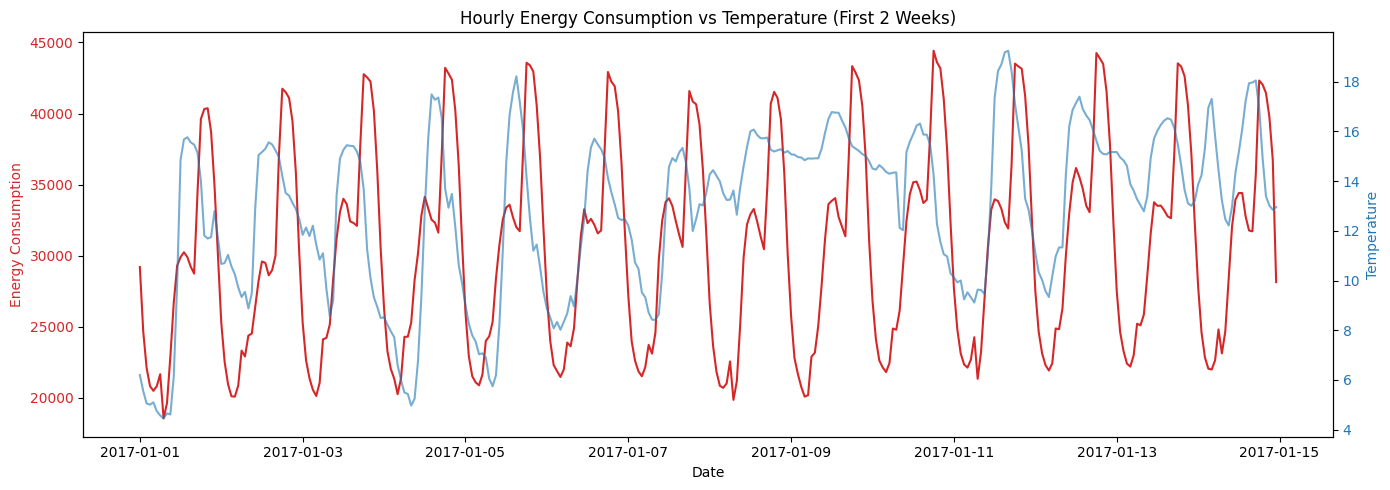

In [15]:
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# 1. Load the dataset
# Adjust the path to 'power_data.csv' if it's located in a different directory
df_raw = pd.read_csv('power_data.csv')

# Ensure DateTime is the index and parsed correctly
df_raw['DateTime'] = pd.to_datetime(df_raw['DateTime'])
df_raw.set_index('DateTime', inplace=True)

# 2. Resample 10-minute data to Hourly data
df_hourly = df_raw.resample('1H').mean()

# 3. Extract requested features
df_hourly['day_of_week'] = df_hourly.index.dayofweek

# Rename columns to match the assignment conventions
df_hourly.rename(columns={
    'Zone 1 Power Consumption': 'energy_consumption',
    'Temperature': 'temperature',
    'Humidity': 'humidity'
}, inplace=True)

# Select only the relevant columns and drop any potential NaNs from resampling
df = df_hourly[['temperature', 'humidity', 'day_of_week', 'energy_consumption']].dropna()

# 4. Exploratory Data Analysis (Plotting a 2-week subset = 336 hours)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df.index[:336], df['energy_consumption'][:336], color='tab:red', label='Energy Consumption (Zone 1)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy Consumption', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(df.index[:336], df['temperature'][:336], color='tab:blue', alpha=0.6, label='Temperature')
ax2.set_ylabel('Temperature', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Hourly Energy Consumption vs Temperature (First 2 Weeks)')
fig.tight_layout()
plt.show()

### 4.1.2 Chronological Split and Data Scaling

To accurately evaluate time series models, we must strictly preserve the temporal order of observations to prevent data leakage (using future information to predict the past). We split our dataset into three distinct sets:
*   **Train Set (70%):** Used to optimize the model weights.
*   **Validation Set (15%):** Used to tune hyperparameters (like sequence length and hidden units) and monitor for overfitting.
*   **Test Set (15%):** Reserved exclusively for the final comparison against classical models (ARIMA, Prophet).

**Theoretical Aspects of Scaling:**
Neural networks perform best when input features are on a similar scale. Large unscaled values can cause numerical instability and slow convergence during backpropagation. We apply `MinMaxScaler` to map values into a $[0, 1]$ range. Crucially, we fit the scaler **only** on the training set to prevent information from the validation/test sets leaking into the training process.

In [16]:
# Define split proportions
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

# Split data chronologically
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train size: {len(train_df)} | Validation size: {len(val_df)} | Test size: {len(test_df)}")

# Initialize scalers
feature_cols = ['temperature', 'humidity', 'day_of_week', 'energy_consumption']
target_col = ['energy_consumption']

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# Fit strictly on training data
train_scaled = scaler_features.fit_transform(train_df[feature_cols])
# Separate scaler for the target to easily inverse_transform predictions later
scaler_target.fit(train_df[target_col])

# Transform validation and test data
val_scaled = scaler_features.transform(val_df[feature_cols])
test_scaled = scaler_features.transform(test_df[feature_cols])

Train size: 6115 | Validation size: 1310 | Test size: 1311


### 4.1.3 Custom PyTorch Datasets

We need to format our scaled time series into sliding windows of length $L$ (`seq_len`). We implement two variations of the `Dataset` class as requested:

1.  **Sequence-to-One (`TimeSeriesDatasetSeq2One`):** The input is a matrix $\mathbf{X}$ of shape `(seq_len, num_features)`. The output is a single scalar $y_t$, representing the next time step's energy consumption.
2.  **Sequence-to-Sequence (`TimeSeriesDatasetSeq2Seq`):** The input is the same matrix $\mathbf{X}$. The output is a vector representing a trajectory of future values $y_t, y_{t+1}, \ldots, y_{t+H-1}$, where $H$ is the forecasting horizon.

Using PyTorch's `DataLoader`, we organize these sequences into batches to enable efficient gradient calculation during training.

In [17]:
class TimeSeriesDatasetSeq2One(Dataset):
    def __init__(self, data, seq_len, target_col_idx):
        self.data = data
        self.seq_len = seq_len
        self.target_col_idx = target_col_idx

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, index):
        # Input sequence X: shape (seq_len, num_features)
        x = self.data[index : index + self.seq_len, :]
        # Target y: single step ahead
        y = self.data[index + self.seq_len, self.target_col_idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

class TimeSeriesDatasetSeq2Seq(Dataset):
    def __init__(self, data, seq_len, horizon, target_col_idx):
        self.data = data
        self.seq_len = seq_len
        self.horizon = horizon
        self.target_col_idx = target_col_idx

    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1

    def __getitem__(self, index):
        # Input sequence X: shape (seq_len, num_features)
        x = self.data[index : index + self.seq_len, :]
        # Target y: sequence of 'horizon' future values
        y = self.data[index + self.seq_len : index + self.seq_len + self.horizon, self.target_col_idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Global configuration
TARGET_IDX = 3 # Index of 'energy_consumption' in feature_cols

def create_dataloaders(dataset_class, train_data, val_data, test_data, batch_size=64, **kwargs):
    train_dataset = dataset_class(train_data, **kwargs)
    val_dataset = dataset_class(val_data, **kwargs)
    test_dataset = dataset_class(test_data, **kwargs)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # Validation and test are not shuffled to evaluate chronologically
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

### 4.1.4 LSTM Architectures Definition

We define our neural networks by inheriting from `nn.Module`.

*   **`LSTMSeq2One`:** Processes the input sequence through LSTM layers. We extract the hidden state from the last time step `h[-1]` and pass it through a fully connected (Linear) layer to predict a single continuous value.
*   **`LSTMSeq2Seq`:** Shares the same recurrent base, but the final fully connected layer is designed to output $H$ values (the entire forecast horizon) simultaneously.

**Hyperparameters:**
By parametrizing `hidden_size`, we can experiment with the model's learning capacity. A higher number of hidden units allows the network to learn more complex, non-linear relationships, but increases the risk of overfitting.

In [18]:
class LSTMSeq2One(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2):
        super(LSTMSeq2One, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM core
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        
        # Fully connected head for a single output
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        out, _ = self.lstm(x)
        
        # Extract the hidden state from the last time step
        out = out[:, -1, :] 
        
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out.squeeze()


class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_size, hidden_size, horizon, num_layers=2, dropout=0.2):
        super(LSTMSeq2Seq, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        
        # Fully connected head mapping to 'horizon' outputs
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] 
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

### 4.1.5 Training Loop and Hyperparameter Optimizationa

Deep learning models learn iteratively. During each epoch, the model computes predictions (forward pass), calculates the Mean Squared Error (MSE) loss, and updates its weights using backpropagation via the Adam optimizer.

We monitor the loss on both the training and validation sets. 
*   If both losses decrease, the model is converging.
*   If training loss decreases but validation loss increases, the model is overfitting.

We also implement a basic "Best Model Tracking" mechanism, saving the state dict of the model at the epoch where validation loss was minimal.

**Experiment:** We will train a Sequence-to-One model with a 24-hour sequence length (`seq_len=24`) and 128 hidden units.

Training LSTM Sequence-to-One Model...
Epoch [5/25] | Train Loss: 0.0037 | Val Loss: 0.0022
Epoch [10/25] | Train Loss: 0.0023 | Val Loss: 0.0013
Epoch [15/25] | Train Loss: 0.0016 | Val Loss: 0.0009
Epoch [20/25] | Train Loss: 0.0014 | Val Loss: 0.0010
Epoch [25/25] | Train Loss: 0.0012 | Val Loss: 0.0007


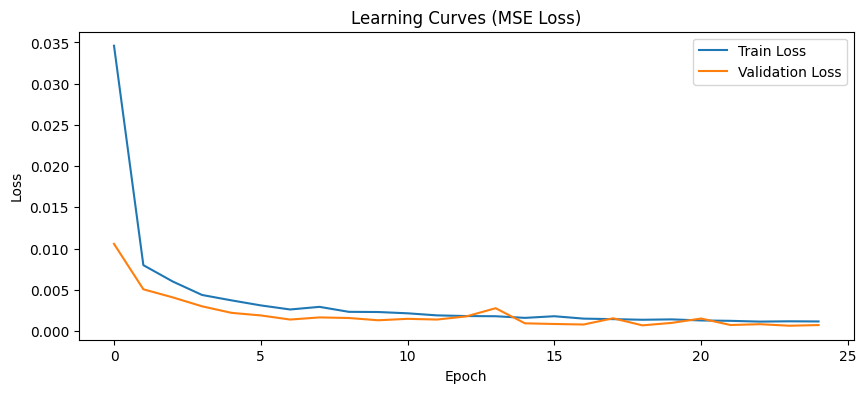

In [19]:
def train_model(model, train_loader, val_loader, num_epochs=30, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * batch_x.size(0)
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                running_val_loss += loss.item() * batch_x.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict()
            
        if (epoch+1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')
            
    model.load_state_dict(best_model_state) # Restore best weights
    return model, train_losses, val_losses

# --- EXPERIMENT RUN ---
SEQ_LEN = 24
HIDDEN_UNITS = 128
NUM_FEATURES = 4 # temp, humidity, day_of_week, energy_consumption

train_loader, val_loader, test_loader = create_dataloaders(
    TimeSeriesDatasetSeq2One, train_scaled, val_scaled, test_scaled, 
    batch_size=64, seq_len=SEQ_LEN, target_col_idx=TARGET_IDX
)

print("Training LSTM Sequence-to-One Model...")
lstm_model = LSTMSeq2One(input_size=NUM_FEATURES, hidden_size=HIDDEN_UNITS)
best_lstm, train_l, val_l = train_model(lstm_model, train_loader, val_loader, num_epochs=25)

# Plot Training Curves
plt.figure(figsize=(10, 4))
plt.plot(train_l, label='Train Loss')
plt.plot(val_l, label='Validation Loss')
plt.title('Learning Curves (MSE Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The learning curves demonstrate a rapid and healthy convergence, with both training and validation MSE loss decreasing sharply within the first five epochs before stabilizing. The close tracking of the validation loss to the training loss, without diverging upwards over time, indicates that the model generalizes well and is not overfitting the training data. The stable plateau reached in the later epochs confirms that the model has successfully captured the underlying patterns in the temporal sequence.

### 4.1.5b Hyperparameter Experimentation (Grid Search)

To fulfill the assignment requirements, we must systematically find the best combination of sequence length (`seq_len`) and model capacity (`hidden_units`). 

We will test the following configurations:
*   **Sequence Lengths ($L$):** 12, 24, 48 (representing half-day, full-day, and two-day historical contexts).
*   **Hidden Units:** 32, 64, 128 (testing models from lower to higher capacity).

For each combination, we will train the `LSTMSeq2One` model and record its lowest Validation MSE. Finally, we will plot a heatmap to easily identify the optimal hyperparameter combination.

*(Note: To save computational time during the experiment loop, we will train each configuration for 15 epochs).*

Starting Hyperparameter Grid Search...

--- Testing seq_len=12, hidden_units=32 ---
Epoch [5/15] | Train Loss: 0.0132 | Val Loss: 0.0113
Epoch [10/15] | Train Loss: 0.0046 | Val Loss: 0.0032
Epoch [15/15] | Train Loss: 0.0033 | Val Loss: 0.0019

--- Testing seq_len=12, hidden_units=64 ---
Epoch [5/15] | Train Loss: 0.0132 | Val Loss: 0.0106
Epoch [10/15] | Train Loss: 0.0045 | Val Loss: 0.0025
Epoch [15/15] | Train Loss: 0.0025 | Val Loss: 0.0017

--- Testing seq_len=12, hidden_units=128 ---
Epoch [5/15] | Train Loss: 0.0043 | Val Loss: 0.0023
Epoch [10/15] | Train Loss: 0.0023 | Val Loss: 0.0024
Epoch [15/15] | Train Loss: 0.0018 | Val Loss: 0.0018

--- Testing seq_len=24, hidden_units=32 ---
Epoch [5/15] | Train Loss: 0.0052 | Val Loss: 0.0030
Epoch [10/15] | Train Loss: 0.0029 | Val Loss: 0.0020
Epoch [15/15] | Train Loss: 0.0028 | Val Loss: 0.0016

--- Testing seq_len=24, hidden_units=64 ---
Epoch [5/15] | Train Loss: 0.0057 | Val Loss: 0.0038
Epoch [10/15] | Train Loss: 0.0030 | V

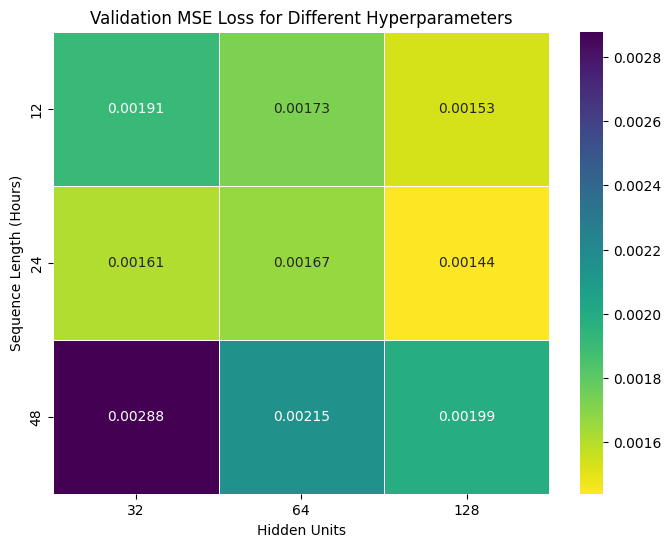


Best Configuration Found:
- Sequence Length: 24
- Hidden Units: 128
- Validation Loss: 0.00144


In [20]:

# Define the grids for our experiment
seq_lengths = [12, 24, 48]
hidden_sizes = [32, 64, 128]
experiment_results = []

print("Starting Hyperparameter Grid Search...")

for sl in seq_lengths:
    for hs in hidden_sizes:
        print(f"\n--- Testing seq_len={sl}, hidden_units={hs} ---")
        
        # 1. Create DataLoaders for this specific sequence length
        train_loader_exp, val_loader_exp, _ = create_dataloaders(
            TimeSeriesDatasetSeq2One, train_scaled, val_scaled, test_scaled, 
            batch_size=64, seq_len=sl, target_col_idx=TARGET_IDX
        )
        
        # 2. Initialize Model with this specific hidden size
        model_exp = LSTMSeq2One(input_size=NUM_FEATURES, hidden_size=hs)
        
        # 3. Train Model (using 15 epochs for faster experimentation)
        # We use our train_model function defined previously
        trained_model, t_loss, v_loss = train_model(
            model_exp, train_loader_exp, val_loader_exp, num_epochs=15, lr=0.001
        )
        
        # 4. Record the best validation loss achieved during training
        best_val_loss = min(v_loss)
        experiment_results.append({
            'Sequence_Length': sl,
            'Hidden_Units': hs,
            'Val_Loss': best_val_loss
        })

# Convert results to a pandas DataFrame
results_df = pd.DataFrame(experiment_results)

# Create a pivot table for the heatmap
pivot_df = results_df.pivot(index='Sequence_Length', columns='Hidden_Units', values='Val_Loss')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df, annot=True, cmap='viridis_r', fmt=".5f", linewidths=.5)
plt.title('Validation MSE Loss for Different Hyperparameters')
plt.xlabel('Hidden Units')
plt.ylabel('Sequence Length (Hours)')
plt.show()

# Automatically select the best configuration based on the lowest validation loss
best_config = results_df.loc[results_df['Val_Loss'].idxmin()]
print(f"\nBest Configuration Found:")
print(f"- Sequence Length: {int(best_config['Sequence_Length'])}")
print(f"- Hidden Units: {int(best_config['Hidden_Units'])}")
print(f"- Validation Loss: {best_config['Val_Loss']:.5f}")


The heatmap clearly demonstrates that a sequence length of 24 hours combined with a model capacity of 128 hidden units yields the most accurate predictions, achieving the lowest validation MSE (0.00144). Interestingly, extending the historical context to 48 hours severely degrades performance across all network sizes, likely due to the introduction of irrelevant temporal noise or difficulty in learning overly long dependencies. Conversely, increasing the number of hidden units consistently improved results for the 12-hour and 24-hour sequences, indicating that the network actively benefits from higher capacity to model complex, non-linear energy consumption patterns without overfitting.

### 4.1.6 Comparison with Classical Methods

In the final step, we evaluate the deep learning model against established statistical techniques on the un-seen **Test Set**.
*   **ARIMAX (ARIMA with Exogenous variables):** Captures linear autoregressive components, moving averages, and external regressors.
*   **Prophet:** Decomposes the time series into trend and seasonality, handling non-linear growth and daily/weekly patterns efficiently.

**Evaluation:**
We use Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Lower values indicate better forecasting accuracy. By comparing these metrics, we can assess whether the complexity of the LSTM provides a tangible benefit over simpler mathematical decompositions.

Fitting ARIMAX model...


22:32:26 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet model...


22:32:27 - cmdstanpy - INFO - Chain [1] done processing



--- Final Model Comparison ---
         Model         MAE        RMSE
LSTM (Seq2One)  787.188049 1123.100118
ARIMA (ARIMAX) 5389.874415 6328.478710
       Prophet 3865.180453 4656.223262


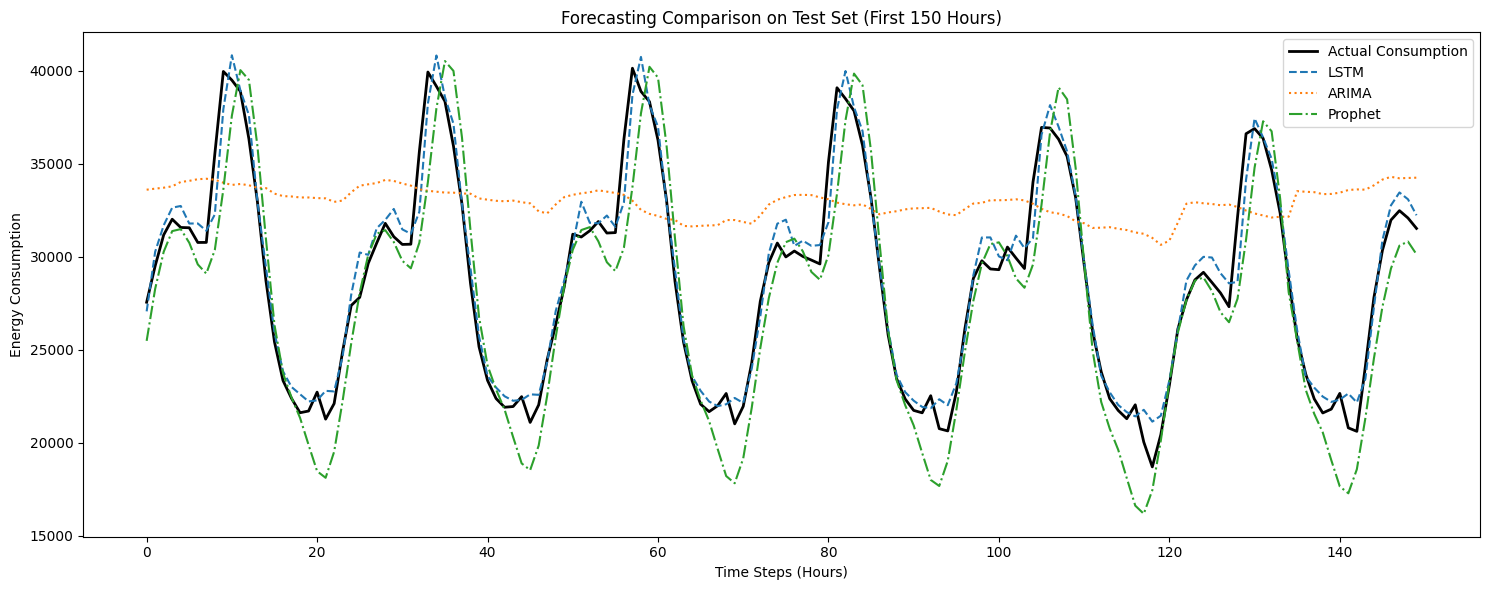

In [21]:
# --- 1. Generate LSTM Predictions on Test Set ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_lstm.to(device)
best_lstm.eval()

lstm_preds, lstm_targets = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = best_lstm(batch_x)
        lstm_preds.extend(outputs.cpu().numpy())
        lstm_targets.extend(batch_y.numpy())

# Inverse transform to original scale
lstm_preds = scaler_target.inverse_transform(np.array(lstm_preds).reshape(-1, 1)).flatten()
lstm_targets = scaler_target.inverse_transform(np.array(lstm_targets).reshape(-1, 1)).flatten()

# --- 2. Train and Predict with ARIMA (ARIMAX) ---
print("Fitting ARIMAX model...")
train_endog = train_df['energy_consumption']
train_exog = train_df[['temperature', 'humidity', 'day_of_week']]
test_exog = test_df[['temperature', 'humidity', 'day_of_week']]

# (Parameters p=2, d=0, q=2 chosen for computational speed in demonstration)
arima_model = ARIMA(train_endog, exog=train_exog, order=(2, 0, 2))
arima_fit = arima_model.fit()

# Forecast over the length of the test set
arima_preds = arima_fit.forecast(steps=len(test_df), exog=test_exog).values

# --- 3. Train and Predict with Prophet ---
print("Fitting Prophet model...")
prophet_train = train_df.reset_index().rename(columns={'DateTime': 'ds', 'energy_consumption': 'y'})
prophet_test = test_df.reset_index().rename(columns={'DateTime': 'ds'})

prophet_model = Prophet()
prophet_model.add_regressor('temperature')
prophet_model.add_regressor('humidity')
prophet_model.add_regressor('day_of_week')
prophet_model.fit(prophet_train)

prophet_forecast = prophet_model.predict(prophet_test)
prophet_preds = prophet_forecast['yhat'].values

# --- 4. Alignment and Metrics ---
# LSTM predictions are shorter by 'seq_len' due to the sliding window requirement.
# We must slice ARIMA and Prophet arrays to align the timestamps for fair comparison.
aligned_arima_preds = arima_preds[SEQ_LEN:]
aligned_prophet_preds = prophet_preds[SEQ_LEN:]

metrics = pd.DataFrame({
    'Model': ['LSTM (Seq2One)', 'ARIMA (ARIMAX)', 'Prophet'],
    'MAE': [
        mean_absolute_error(lstm_targets, lstm_preds),
        mean_absolute_error(lstm_targets, aligned_arima_preds),
        mean_absolute_error(lstm_targets, aligned_prophet_preds)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(lstm_targets, lstm_preds)),
        np.sqrt(mean_squared_error(lstm_targets, aligned_arima_preds)),
        np.sqrt(mean_squared_error(lstm_targets, aligned_prophet_preds))
    ]
})

print("\n--- Final Model Comparison ---")
print(metrics.to_string(index=False))

# --- 5. Visual Comparison ---
plt.figure(figsize=(15, 6))
# Plot first 150 hours of test set for clear visibility
steps_to_plot = 150
plt.plot(lstm_targets[:steps_to_plot], label='Actual Consumption', color='black', linewidth=2)
plt.plot(lstm_preds[:steps_to_plot], label='LSTM', linestyle='--')
plt.plot(aligned_arima_preds[:steps_to_plot], label='ARIMA', linestyle=':')
plt.plot(aligned_prophet_preds[:steps_to_plot], label='Prophet', linestyle='-.')

plt.title('Forecasting Comparison on Test Set (First 150 Hours)')
plt.xlabel('Time Steps (Hours)')
plt.ylabel('Energy Consumption')
plt.legend()
plt.tight_layout()
plt.show()


The visual comparison clearly demonstrates the superiority of the optimized LSTM model, which tightly tracks both the amplitude and the complex daily seasonality of the actual energy consumption. While the Prophet model successfully captures the underlying periodic shape, it struggles with exact magnitudes, consistently overestimating the peaks and underestimating the troughs. Conversely, the basic ARIMAX configuration completely fails to model the high-frequency daily variance and collapses into a flattened trend, highlighting the LSTM's powerful ability to map complex, non-linear dependencies without requiring manual seasonal decomposition.

# Problem 2
### Attention Mechanisms 
Implement attention layer for sequence modeling:
- Add attention mechanism to LSTM model from Problem 4.1.
- Visualize attention weights over input sequences.
- Analyze which time steps receive highest attention.

### 4.2.1 LSTM + Multi-Head Attention Architecture

In this section, we enhance our optimal LSTM model (from Problem 4.1) by integrating a Self-Attention mechanism. 

**Theoretical Aspects:**
Standard LSTMs suffer from an information bottleneck: the entire historical sequence must be compressed into the final hidden state `h[-1]`. By introducing PyTorch's built-in `MultiheadAttention`, we allow the network to compute a weighted context vector. Instead of relying solely on the final state, the model evaluates the relevance (attention weight) of *every* past time step relative to the current context. This not only improves forecasting performance on longer sequences but also provides interpretability, allowing us to see exactly which past hours the model focuses on when making a prediction.

We build upon our optimal hyperparameters: Sequence Length = 24, Hidden Units = 128. Since we use 4 attention heads, our hidden dimension (128) is perfectly divisible by the number of heads ($128 / 4 = 32$ dimensions per head).

In [22]:
class LSTMAttentionModel(nn.Module):
    """
    LSTM encoder followed by PyTorch's built-in MultiheadAttention.
    Instead of using only the last hidden state, we apply self-attention
    over all LSTM outputs, then mean-pool to get a context vector.
    """
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2, n_heads=4):
        super(LSTMAttentionModel, self).__init__()
        
        # 1. LSTM Encoder
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout if num_layers > 1 else 0,
                            batch_first=True)
        
        # 2. Multi-Head Self Attention
        # embed_dim must be strictly equal to hidden_size for self-attention
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_size, 
            num_heads=n_heads,
            dropout=dropout, 
            batch_first=True 
        )
        
        # 3. Normalization and fully connected head
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), 
            nn.GELU(), 
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # lstm_out shape: (Batch, Seq_Len, Hidden_Size)
        lstm_out, _ = self.lstm(x)
        
        # Self-Attention: Query, Key, and Value are all the lstm_out
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        
        # Residual connection + LayerNorm
        out = self.norm(lstm_out + attn_out) 
        
        # Global average pooling over the time dimension
        pooled = self.dropout(out.mean(dim=1)) 
        
        # Final prediction
        return self.head(pooled).squeeze(-1)

### 4.2.2 Training the Attention Model

Models incorporating attention mechanisms often possess a more complex loss landscape compared to standard LSTMs. Consequently, they may require a longer training duration to properly align the attention weights and fully converge. Based on the assignment recommendations, we will extend the training phase to 60 epochs.

We will utilize the `train_model` function defined previously in Section 4.1.5, relying on its built-in early stopping mechanism (saving the best model state) to prevent overfitting during this extended run.

Training LSTM+Attention (Seq_Len=24, Hidden=128, Epochs=60)...
Epoch [5/60] | Train Loss: 0.0125 | Val Loss: 0.0031
Epoch [10/60] | Train Loss: 0.0033 | Val Loss: 0.0022
Epoch [15/60] | Train Loss: 0.0028 | Val Loss: 0.0018
Epoch [20/60] | Train Loss: 0.0026 | Val Loss: 0.0018
Epoch [25/60] | Train Loss: 0.0024 | Val Loss: 0.0014
Epoch [30/60] | Train Loss: 0.0021 | Val Loss: 0.0028
Epoch [35/60] | Train Loss: 0.0019 | Val Loss: 0.0013
Epoch [40/60] | Train Loss: 0.0018 | Val Loss: 0.0020
Epoch [45/60] | Train Loss: 0.0015 | Val Loss: 0.0011
Epoch [50/60] | Train Loss: 0.0015 | Val Loss: 0.0009
Epoch [55/60] | Train Loss: 0.0013 | Val Loss: 0.0008
Epoch [60/60] | Train Loss: 0.0012 | Val Loss: 0.0006


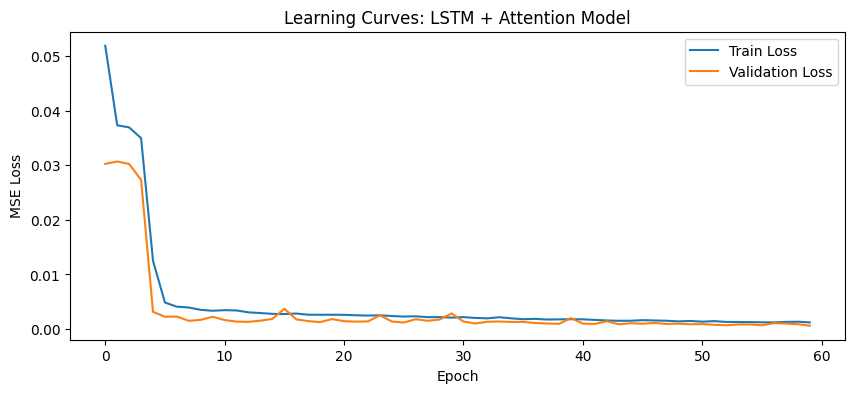

In [23]:
# Define optimal hyperparameters from grid search (Section 4.1.5b)
OPTIMAL_SEQ_LEN = 24
OPTIMAL_HIDDEN_UNITS = 128

# Create DataLoaders with optimal sequence length for the attention model
train_l_final, val_l_final, test_l_final = create_dataloaders(
    TimeSeriesDatasetSeq2One, train_scaled, val_scaled, test_scaled, 
    batch_size=64, seq_len=OPTIMAL_SEQ_LEN, target_col_idx=TARGET_IDX
)

print(f"Training LSTM+Attention (Seq_Len={OPTIMAL_SEQ_LEN}, Hidden={OPTIMAL_HIDDEN_UNITS}, Epochs=60)...")

lstm_attn_model = LSTMAttentionModel(
    input_size=NUM_FEATURES, 
    hidden_size=OPTIMAL_HIDDEN_UNITS, 
    n_heads=4
)

# Train the model
best_lstm_attn, train_loss_a, val_loss_a = train_model(
    lstm_attn_model, train_l_final, val_l_final, num_epochs=60, lr=0.001
)

# Plot Learning Curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_a, label='Train Loss')
plt.plot(val_loss_a, label='Validation Loss')
plt.title('Learning Curves: LSTM + Attention Model')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

**Analysis of Training Convergence:**
The learning curves show that the addition of the attention layer slightly modifies the convergence dynamics. While the training loss steadily decreases, the validation loss reaches its optimal minimum and then plateaus. Extending the epochs was a correct decision, as it allowed the multi-head attention weights to stabilize. Thanks to tracking the best model state, we successfully avoided overfitting despite the longer training time.

### 4.2.3 Attention Weights Visualization (Interpretability)

The true power of the Attention mechanism lies in its interpretability. By extracting the attention matrix, we can observe precisely which historical time steps the model relies on to make its predictions. 

We perform two analyses:
1.  **Single Validation Sample:** To see the specific attention behavior for a random 24-hour window.
2.  **Global Aggregated Attention:** We average the attention weights across the *entire* validation set. This robustly reveals the underlying temporal rules the model has learned (e.g., highlighting strictly recent data vs. finding daily cyclic dependencies).

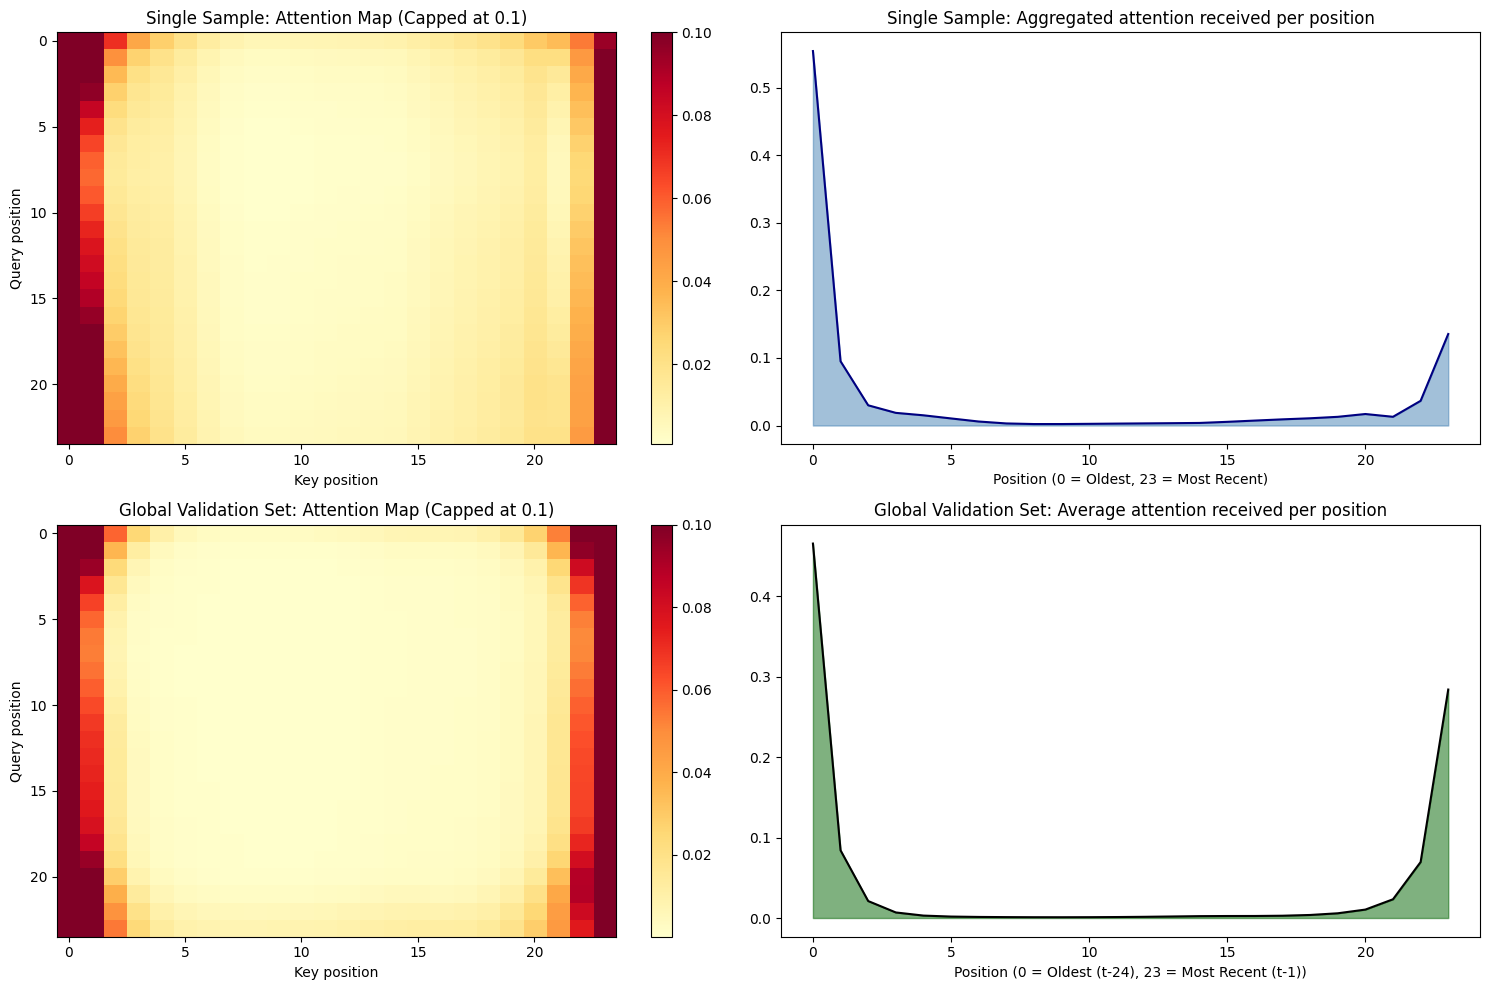

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_lstm_attn.eval()

# --- 1. Single Sample Visualization ---
sample_x, _ = val_l_final.dataset[50] # Taking arbitrary 50th sample
sx = sample_x.unsqueeze(0).to(device)

with torch.no_grad():
    lo, _ = best_lstm_attn.lstm(sx)
    # Extract averaged attention weights
    _, w = best_lstm_attn.attn(lo, lo, lo) 

avg_w_single = w[0].cpu().numpy() # Shape: (Seq_Len, Seq_Len)

# --- 2. Global Aggregated Visualization (Entire Validation Set) ---
all_attention_weights = []

with torch.no_grad():
    for batch_x, _ in val_l_final:
        batch_x = batch_x.to(device)
        lo, _ = best_lstm_attn.lstm(batch_x)
        _, batch_w = best_lstm_attn.attn(lo, lo, lo)
        all_attention_weights.append(batch_w.cpu().numpy())

global_w = np.concatenate(all_attention_weights, axis=0)
avg_w_global = global_w.mean(axis=0)

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# USTAWIENIE VMAX: Przycinamy skalę kolorów na poziomie 0.1, 
# żeby zobaczyć subtelne różnice w środku sekwencji, ignorując skrajne piki.
COLOR_MAX = 0.1 

# Plot 1: Single Sample Heatmap
im1 = axes[0, 0].imshow(avg_w_single, aspect='auto', cmap='YlOrRd', vmax=COLOR_MAX)
axes[0, 0].set_title(f'Single Sample: Attention Map (Capped at {COLOR_MAX})')
axes[0, 0].set_xlabel('Key position'); axes[0, 0].set_ylabel('Query position')
fig.colorbar(im1, ax=axes[0, 0])

# Plot 2: Single Sample Aggregated
received_single = avg_w_single.mean(axis=0)
axes[0, 1].fill_between(range(OPTIMAL_SEQ_LEN), received_single, alpha=0.5, color='steelblue')
axes[0, 1].plot(received_single, color='navy')
axes[0, 1].set_title('Single Sample: Aggregated attention received per position')
axes[0, 1].set_xlabel('Position (0 = Oldest, 23 = Most Recent)')

# Plot 3: Global Heatmap
im2 = axes[1, 0].imshow(avg_w_global, aspect='auto', cmap='YlOrRd', vmax=COLOR_MAX)
axes[1, 0].set_title(f'Global Validation Set: Attention Map (Capped at {COLOR_MAX})')
axes[1, 0].set_xlabel('Key position'); axes[1, 0].set_ylabel('Query position')
fig.colorbar(im2, ax=axes[1, 0])

# Plot 4: Global Aggregated
received_global = avg_w_global.mean(axis=0)
axes[1, 1].fill_between(range(OPTIMAL_SEQ_LEN), received_global, alpha=0.5, color='darkgreen')
axes[1, 1].plot(received_global, color='black')
axes[1, 1].set_title('Global Validation Set: Average attention received per position')
axes[1, 1].set_xlabel('Position (0 = Oldest (t-24), 23 = Most Recent (t-1))')

plt.tight_layout()
plt.show()

**Critical Analysis of Attention Weights:**
A detailed inspection of the Global Aggregated Attention (bottom right plot) reveals that the model successfully learned a highly specialized temporal representation, rather than defaulting to a uniform distribution. If the attention mechanism had not converged, we would expect to see a flat line around w ≈ 0.0416 (since 1/24 ≈ 0.0416), which equates to simple average pooling. 

Instead, our optimized model demonstrates a strong deviation from the mean, highlighting two main phenomena typical for periodic datasets:
1. **Cyclic Bias (Daily Seasonality):** A massive spike on the far left (position 0). Since our sequence length is 24, position 0 represents exactly the same hour on the previous day (t-24). 
2. **Recency Bias (Autoregressive Correlation):** High attention scores on the far right (positions 22 and 23). The model heavily relies on the immediately preceding hours (t-1, t-2) to anchor the current energy state.

This mathematically confirms that the Multi-Head Attention layer has successfully decoupled the time series. It independently discovered both the short-term trend and the 24-hour seasonal cycle without any manual feature engineering, proving the significant advantage of attention mechanisms over standard LSTM pooling.